**Original (mass collapses to a delta at $x = -\pi/2$):**

$$\frac{\partial p}{\partial t} = \frac{\partial}{\partial x}\left[\cos(x)\, p\right], \qquad x \in [-\pi, 0]$$

**Sloshing variant — uniform time-periodic drift with reflective walls:**

$$\frac{\partial p}{\partial t} + V(t)\,\frac{\partial p}{\partial x} = 0, \qquad V(t) = A\cos(\omega t)$$

Characteristics are $x(t) = x_0 + (A/\omega)\sin(\omega t)$. Choosing $x_0 = -\pi/2$ and $A/\omega = \pi/2$ makes the centroid kiss $x = 0$ and $x = -\pi$ at the turn-around moments (when $V(t) = 0$). Reflective walls bounce any tail that overshoots, so mass is conserved exactly.

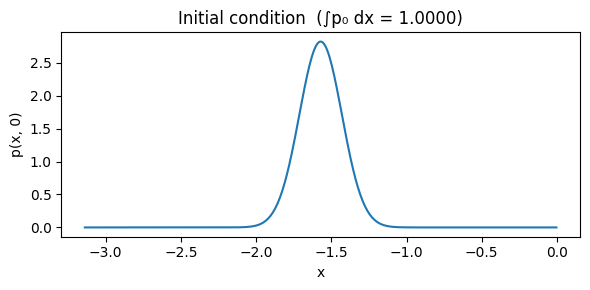

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Domain
x_min, x_max = -np.pi, 0.0
N = 400
dx = (x_max - x_min) / N
x = x_min + (np.arange(N) + 0.5) * dx        # cell centers
x_iface = x_min + np.arange(N + 1) * dx      # cell interfaces

# Initial condition: narrow Gaussian centered at the midpoint of the domain
x0, sigma = -np.pi / 2, 0.2
p0_unnorm = np.exp(-((x - x0) / sigma) ** 2)
alpha = 1.0 / (p0_unnorm.sum() * dx)
p0 = alpha * p0_unnorm

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, p0)
ax.set_xlabel("x"); ax.set_ylabel("p(x, 0)")
ax.set_title(f"Initial condition  (∫p₀ dx = {(p0*dx).sum():.4f})")
plt.tight_layout(); plt.show()

In [2]:
# Method of lines: keep the upwind FV spatial discretization (reflective walls),
# but hand the semi-discrete ODE system to scipy's adaptive RK45 integrator
# instead of the hand-rolled Euler loop.
from scipy.integrate import solve_ivp

A     = np.pi / 2     # drift amplitude
omega = 1.0           # angular frequency  (A/omega = pi/2 => centroid reaches the walls)

A     = 1.0           # equivalent slower setting
omega = 2 / np.pi     # same A/omega = pi/2, just a different clock

def v_fn(x, t):
    # spatially uniform, time-periodic drift
    return A * np.cos(omega * t) * np.ones_like(x)

def upwind_flux(p, v_iface):
    vp = np.maximum(v_iface, 0.0)
    vm = np.minimum(v_iface, 0.0)
    F = np.empty(N + 1)
    F[1:-1] = vp[1:-1] * p[:-1] + vm[1:-1] * p[1:]   # interior interfaces
    F[0]  = 0.0   # reflective wall at x = -pi
    F[-1] = 0.0   # reflective wall at x = 0
    return F

def rhs(t, p):
    v_iface = v_fn(x_iface, t)
    F = upwind_flux(p, v_iface)
    return -(F[1:] - F[:-1]) / dx

T_final    = 4 * np.pi / omega          # two full periods
n_frames   = 160
save_times = np.linspace(0.0, T_final, n_frames + 1)

sol = solve_ivp(
    rhs,
    t_span=(0.0, T_final),
    y0=p0,
    method="RK45",
    t_eval=save_times,
    rtol=1e-6, atol=1e-9,
    max_step=0.5 * dx / A,    # CFL-like guardrail so RK45 doesn't take an unstable step
)

assert sol.success, sol.message
snapshots = sol.y.T            # shape (n_frames+1, N)
times     = sol.t
mass      = snapshots.sum(axis=1) * dx
print(f"RK45:  nfev = {sol.nfev},  frames = {len(times)},  final t = {times[-1]:.4f}")
print(f"mass:  min = {mass.min():.6f},  max = {mass.max():.6f}")

RK45:  nfev = 30182,  frames = 161,  final t = 19.7392
mass:  min = 1.000000,  max = 1.000000


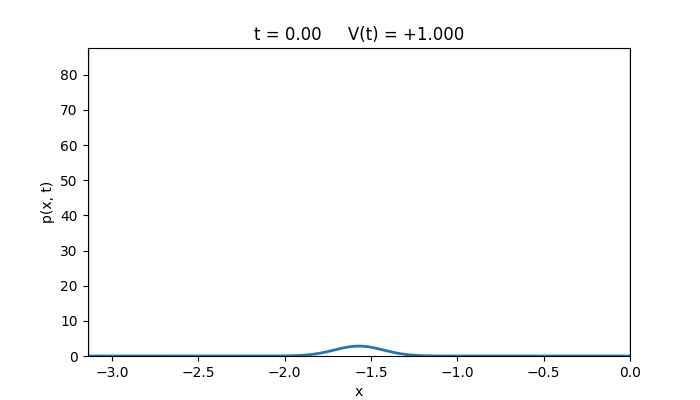

In [3]:
from IPython.display import Image

fig, ax = plt.subplots(figsize=(7, 4))
(line,) = ax.plot(x, snapshots[0], lw=2)
ax.axvline(x_min, color="k", lw=1.0, alpha=0.6)
ax.axvline(x_max, color="k", lw=1.0, alpha=0.6)
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, snapshots.max() * 1.05)
ax.set_xlabel("x"); ax.set_ylabel("p(x, t)")
title = ax.set_title("")

def update(i):
    line.set_ydata(snapshots[i])
    title.set_text(f"t = {times[i]:.2f}     V(t) = {A*np.cos(omega*times[i]):+.3f}")
    return line, title

anim = FuncAnimation(fig, update, frames=len(snapshots), interval=50, blit=False)

gif_path = "1d_sloshing.gif"
anim.save(gif_path, writer=PillowWriter(fps=24))
plt.close(fig)
Image(filename=gif_path)